In [1]:
import pandas as pd

# IBM Telco dataset: one row per customer; Churn = did they leave last month
# the notebook sits in notebooks/, so "../" goes up to reach data/
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

# (rows, columns) -> rows are customers
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**What I see**
- 7043 customers, 21 columns: customerID, 19 features, and Churn (the target, Yes/No).
- customerID is a label only; drop it before modelling.
- Most columns are Yes/No text; SeniorCitizen is already 0/1.
- tenure = months as a customer, likely a strong churn signal.
- "No phone service" / "No internet service" repeat what PhoneService / InternetService already say.

In [2]:
# type of every column and how many non-empty values it has
# watch for a column that should be a number but shows up as object (text)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**What I see**
- No NaN in any column (7043 non-null everywhere).
- TotalCharges is stored as text (object) although it's money, so some values can't be read as numbers. Probably blanks, which pandas doesn't count as missing.
- MonthlyCharges is already a number (float64).

In [4]:
# Find the values that break TotalCharges

# try to turn every value into a number; errors="coerce" turns failures into NaN
total = pd.to_numeric(df["TotalCharges"], errors="coerce")

# the rows that failed, with their tenure and charges, to see what they have in common
bad = total.isna()
print(bad.sum(), "rows could not be converted")
df.loc[bad, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

11 rows could not be converted


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**What I see**
- 11 rows have a blank TotalCharges, and all 11 have tenure 0: brand-new customers who haven't been billed yet.
- The blank means "nothing charged so far", so the correct value is 0, not a median.
- Decision: convert TotalCharges to a number and fill these 11 with 0 (a fixed rule, safe before the split).

In [5]:
# Fix TotalCharges



# tenure 0 = new customers not billed yet, so their total so far is 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# check: now a number, and exactly the 11 new customers have 0
print(df["TotalCharges"].dtype, "|", (df["TotalCharges"] == 0).sum(), "customers with 0 total")

float64 | 11 customers with 0 total


In [9]:
# How many customers left?


# customers who left vs stayed, as counts and as shares of all customers
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3).map("{:.1%}".format))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: object


**What I see**
- 5,174 stayed (73.5%), 1,869 left (26.5%): about 1 in 4 customers churned.
- Always predicting "No" would be 73.5% accurate and catch zero churners, so accuracy is misleading here.
- I'll judge models with Average Precision (random baseline ~0.265), plus precision and recall.

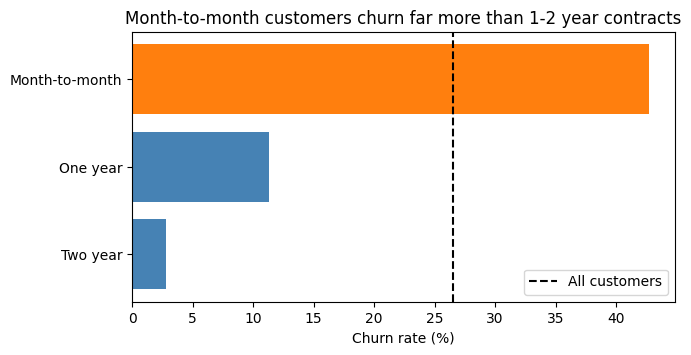

In [10]:
# Churn rate by contract type


import matplotlib.pyplot as plt

# churn rate per contract = % of customers in that group who left
churned = df["Churn"] == "Yes"
rate = churned.groupby(df["Contract"]).mean().sort_values() * 100

# orange = the highest-risk group, dashed line = the overall churn rate
colors = ["tab:orange" if v == rate.max() else "steelblue" for v in rate.values]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(rate.index, rate.values, color=colors)
ax.axvline(churned.mean() * 100, color="black", linestyle="--", label="All customers")
ax.set_title("Month-to-month customers churn far more than 1-2 year contracts")
ax.set_xlabel("Churn rate (%)")
ax.legend()
plt.show()

**What I see**
- Month-to-month customers churn at ~43%, one-year at ~11%, two-year at ~3% (average 26.5%).
- Month-to-month is the highest-risk group by far, about 15x the two-year rate.
- This is correlation, not proof: month-to-month customers may differ in other ways (newer, more price-sensitive). Contract must go into the model as a category.

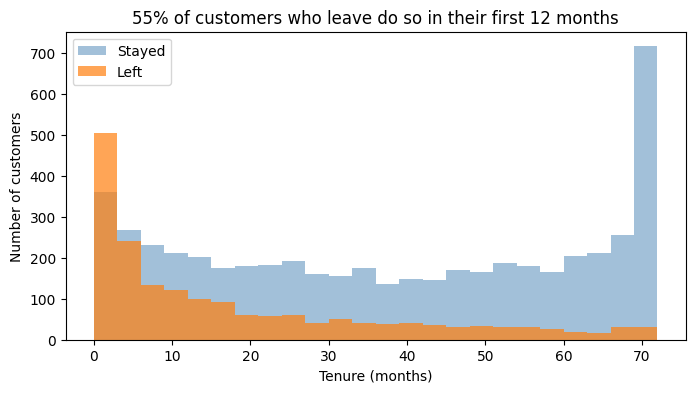

In [15]:
# Tenure for customers who left vs stayed


# same bins for both groups, so the bars line up and can be compared
bins = range(0, 75, 3)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df.loc[~churned, "tenure"], bins=bins, alpha=0.5, color="steelblue", label="Stayed")
ax.hist(df.loc[churned, "tenure"], bins=bins, alpha=0.7, color="tab:orange", label="Left")
ax.set_title("55% of customers who leave do so in their first 12 months")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of customers")
ax.legend()
plt.show()

In [14]:
# of all customers who left, what share left within their first 12 months?
early_share = (df.loc[churned, "tenure"] <= 12).mean()
print(f"{early_share:.1%} of churners left within 12 months")

55.5% of churners left within 12 months


**What I see**
- 55.5% of churners left within their first 12 months; the first 3 months are the riskiest (more leave than stay).
- Churn falls steadily with tenure; long-time customers (60+ months) rarely leave.
- Business angle: the first year, especially the first 3 months, is where retention effort matters most.
- I checked the title's claim with a number instead of trusting my eye.

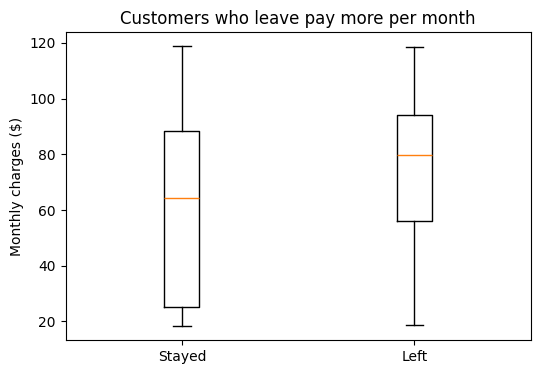

In [16]:
# Monthly charges, left vs stayed

# one box per group; the line inside each box is the median
groups = [df.loc[~churned, "MonthlyCharges"], df.loc[churned, "MonthlyCharges"]]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(groups, tick_labels=["Stayed", "Left"])
ax.set_title("Customers who leave pay more per month")
ax.set_ylabel("Monthly charges ($)")
plt.show()

**What I see**
- Median monthly charge: ~$80 for customers who left vs ~$64 for those who stayed.
- Many stayers pay very little (~$25): simple, cheap plans rarely churn.
- The boxes overlap heavily, so price alone can't separate the groups; the model has to combine features.

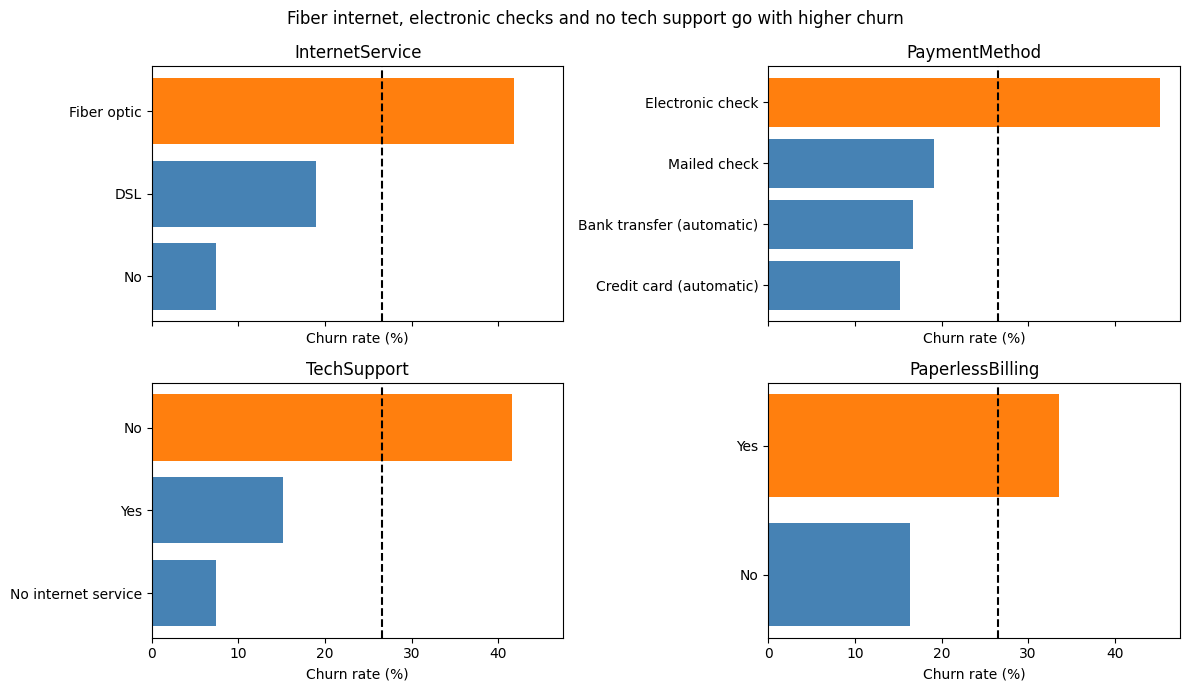

In [18]:
# Churn rate across 4 features at once (2×2 grid)

cols = ["InternetService", "PaymentMethod", "TechSupport", "PaperlessBilling"]
avg = churned.mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(12, 7),sharex = True)
for col, ax in zip(cols, axes.flat):
    # churn rate per group; orange = above the overall average
    rate = churned.groupby(df[col]).mean().sort_values() * 100
    ax.barh(rate.index, rate.values, color=["tab:orange" if v > avg else "steelblue" for v in rate.values])
    ax.axvline(avg, color="black", linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("Churn rate (%)")

fig.suptitle("Fiber internet, electronic checks and no tech support go with higher churn")
plt.tight_layout()
plt.show()

**What I see**
- Fiber optic (~42%), electronic check (~45%), no tech support (~42%) and paperless billing (~34%) all churn above the 26.5% average.
- Automatic payments (bank transfer, credit card) churn ~15-17%, so paying manually goes with leaving.
- "No internet service" churns least (~7%): the same phone-only customers repeated across many columns.
- Panels now share one x-axis scale so bar lengths compare fairly.

In [19]:
# How related are the 3 number columns?


# correlation between the three number columns (-1 to +1)
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr().round(2)

,tenure,MonthlyCharges,TotalCharges
tenure,1.00,0.25,0.83
MonthlyCharges,0.25,1.00,0.65
TotalCharges,0.83,0.65,1.00


**What I see**
- tenure and TotalCharges correlate at 0.83: TotalCharges is roughly tenure x MonthlyCharges.
- tenure and MonthlyCharges barely relate (0.25), so they carry different information.
- Decision: keep all three. Correlated features don't hurt predictions much (regularized logistic regression, trees), but I'll be careful reading individual coefficients.

### Features and target

In [20]:
# target as 1/0: 1 = left, 0 = stayed (models need numbers, not "Yes"/"No")
y = (df["Churn"] == "Yes").astype(int)

# customerID is only a label and Churn is the answer; everything else is a feature
X = df.drop(columns=["customerID", "Churn"])
print(X.shape, "| churn rate:", round(y.mean(), 3))

(7043, 19) | churn rate: 0.265


In [21]:
# Train/test split, now stratified

from sklearn.model_selection import train_test_split

# 20% held out for the final check; stratify=y keeps 26.5% churners in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape, X_test.shape)
print("Churn rate - train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

(5634, 19) (1409, 19)
Churn rate - train: 0.265 | test: 0.265


### The preparation pipeline



In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes("number").columns
cat_cols = X_train.select_dtypes("object").columns

# numbers: same scale for every column; text: one 0/1 column per category
prep = make_column_transformer(
    (StandardScaler(), num_cols),
    (OneHotEncoder(handle_unknown="ignore"), cat_cols))

print(len(num_cols), "number columns:", list(num_cols))
print(len(cat_cols), "text columns")

4 number columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
15 text columns


### Baseline and the first real model

In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# baseline: gives every customer the same 26.5% churn chance (no skill)
# logistic regression: weighted sum of features -> sigmoid -> probability
models = {"Baseline": DummyClassifier(strategy="prior"),
          "Logistic Regression": LogisticRegression(max_iter=1000)}

results = {}
for name, model in models.items():
    # for classifiers, cv=5 automatically keeps the churn rate the same in every fold
    scores = cross_val_score(make_pipeline(prep, model), X_train, y_train, cv=5, scoring="average_precision")
    results[name] = scores.mean()
    print(f"{name}: AP {scores.mean():.3f} (+/- {scores.std():.3f})")

Baseline: AP 0.265 (+/- 0.000)
Logistic Regression: AP 0.662 (+/- 0.028)


**What I see**
- Baseline AP 0.265 = the churn rate: no ranking skill, same in every fold.
- Logistic regression AP 0.662 (+/- 0.028): about 2.5x the baseline.
- Differences between models smaller than ~0.03 may be fold noise.

In [26]:
# A small helper, and the decision tree

from sklearn.tree import DecisionTreeClassifier

# same pipeline, same folds, same metric for every model, so they compare fairly
def cv_ap(name, model):
    scores = cross_val_score(make_pipeline(prep, model), X_train, y_train, cv=5, scoring="average_precision")
    results[name] = scores.mean()
    print(f"{name}: AP {scores.mean():.3f} (+/- {scores.std():.3f})")

# no depth limit: keeps splitting until every leaf is pure -> memorizes the training data
cv_ap("Decision Tree (no limit)", DecisionTreeClassifier(random_state=42))
# depth 5: at most 5 questions in a row
cv_ap("Decision Tree (depth 5)", DecisionTreeClassifier(max_depth=5, random_state=42))

Decision Tree (no limit): AP 0.360 (+/- 0.010)
Decision Tree (depth 5): AP 0.600 (+/- 0.028)


**What I see**
- Unlimited tree: AP 0.360, barely above baseline. It memorized the training data (overfitting), and its pure leaves give only 0% or 100%, which can't rank customers.
- Depth-5 tree: AP 0.600. Limiting depth keeps only general patterns.
- Still below logistic regression (0.662): a single tree is a rough, unstable model.

In [27]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

# 300 trees, each on a random sample of rows and features; predictions are averaged
# min_samples_leaf=5: every leaf needs at least 5 customers, so no leaf memorizes one person
# n_jobs=-1: use all CPU cores to train faster
cv_ap("Random Forest", RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                              random_state=42, n_jobs=-1))

Random Forest: AP 0.663 (+/- 0.032)


**What I see**
- Random Forest AP 0.663, up from 0.600 for a single tree: averaging many trees cancels much of their individual overfitting.
- It ties logistic regression (0.662); the 0.001 difference is far inside the ~0.03 fold noise.
- Hint: the churn signal may be mostly additive, which a linear model already captures.

In [28]:
# XGBoost (gradient boosting)

from xgboost import XGBClassifier

# 300 small trees built in sequence, each correcting the errors of the ones before
# learning_rate=0.05: each tree only corrects a little, which is slower but more careful
# subsample / colsample_bytree: each tree sees 80% of rows and features, which adds variety
cv_ap("XGBoost", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                               subsample=0.8, colsample_bytree=0.8, random_state=42))

XGBoost: AP 0.667 (+/- 0.030)


**What I see**
- XGBoost AP 0.667, Random Forest 0.663, Logistic Regression 0.662: a three-way tie inside the ~0.03 fold noise.
- Boosting (trees in sequence) didn't clearly beat bagging (trees in parallel) or a linear model here.

In [29]:
# K-Nearest Neighbours (KNN)


from sklearn.neighbors import KNeighborsClassifier

# k=5: probabilities can only be 0, 0.2, 0.4, 0.6, 0.8 or 1 (6 possible values)
cv_ap("KNN (k=5)", KNeighborsClassifier(n_neighbors=5))
# k=50: probabilities in steps of 0.02, so customers can be ranked much more finely
cv_ap("KNN (k=50)", KNeighborsClassifier(n_neighbors=50))

KNN (k=5): AP 0.508 (+/- 0.016)
KNN (k=50): AP 0.624 (+/- 0.028)


**What I see**
- KNN k=5: AP 0.508, k=50: AP 0.624. Small k gives coarse, noisy probabilities (overfits); larger k smooths them.
- Still below the top three (~0.66): distances are blunt with many one-hot columns, and prediction is slow because every customer is compared with all training customers.

In [30]:
# Support Vector Machine (SVM)

from sklearn.svm import SVC

# RBF kernel: allows a curved boundary
# C=1.0: how strictly it avoids mistakes on training data (higher = stricter, can overfit)
cv_ap("SVM (RBF)", SVC(kernel="rbf", C=1.0))

SVM (RBF): AP 0.644 (+/- 0.027)


**What I see**
- SVM (RBF, untuned): AP 0.644, slightly below the top three (~0.66), within fold noise.
- Scales poorly to large data (training time grows fast with rows) and gives distances, not probabilities, by default.

In [31]:
# Neural network (MLP)


from sklearn.neural_network import MLPClassifier

# 2 hidden layers: 32 neurons, then 16
# alpha: penalty on large weights (like Ridge), to limit overfitting
# early_stopping: keeps 10% of the training fold aside and stops when that score stops improving
cv_ap("MLP (32, 16)", MLPClassifier(hidden_layer_sizes=(32, 16), alpha=1e-3, max_iter=500,
                                    early_stopping=True, random_state=42))

MLP (32, 16): AP 0.651 (+/- 0.029)


**What I see**
- MLP AP 0.651, inside the top group. A small neural network found nothing the simpler models missed.
- Five very different models sit within ~0.02 of each other: the data, not the algorithm, sets the ceiling.

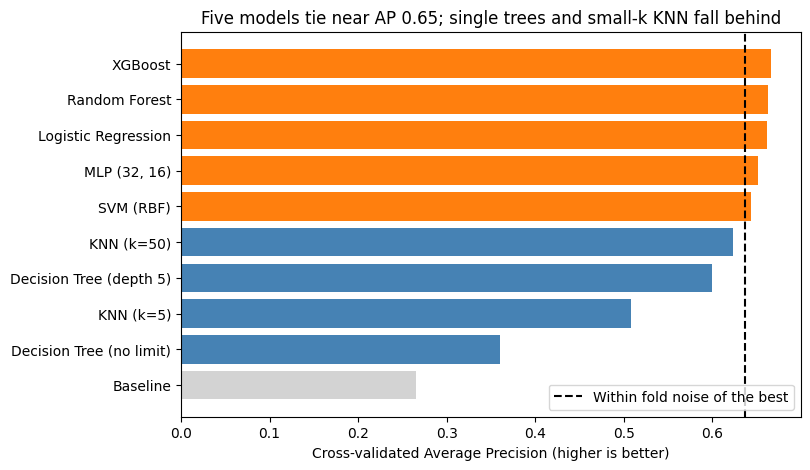

In [33]:
# Chart of all models


res = pd.Series(results).sort_values()
best = res.max()

# models within ~0.03 of the best are tied with it, given the fold-to-fold noise
colors = ["lightgrey" if k == "Baseline" else "tab:orange" if v >= best - 0.03 else "steelblue"
          for k, v in res.items()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(res.index, res.values, color=colors)
ax.axvline(best - 0.03, color="black", linestyle="--", label="Within fold noise of the best")
ax.set_title("Five models tie near AP 0.65; single trees and small-k KNN fall behind")
ax.set_xlabel("Cross-validated Average Precision (higher is better)")
ax.legend(loc="lower right")
plt.show()

**Model choice**
- XGBoost, Random Forest, Logistic Regression, MLP and SVM tie within fold noise (AP 0.644-0.667).
- I choose Logistic Regression: same accuracy, fastest, gives real probabilities, and each coefficient shows how a feature raises or lowers churn risk, so the retention team can see why a customer is flagged.
- Decided before touching the test set.

### tune logistic regression



In [34]:
from sklearn.model_selection import GridSearchCV

# try a range of penalty strengths; each scored with 5-fold CV on training data only
C_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10]
lr_grid = GridSearchCV(make_pipeline(prep, LogisticRegression(max_iter=1000)),
                       {"logisticregression__C": C_values}, cv=5, scoring="average_precision")
lr_grid.fit(X_train, y_train)
print("Best C:", lr_grid.best_params_["logisticregression__C"], "| CV AP:", round(lr_grid.best_score_, 3))

Best C: 1 | CV AP: 0.662


**What I see**
- Tuning C (0.01-10) picked C=1, the default; CV AP stays 0.662.
- Not at the edge of the grid, so the range was wide enough. Tuning confirmed the default rather than improving it.

In [37]:
# The test set, used once


from sklearn.metrics import average_precision_score, roc_auc_score

# GridSearchCV already refit the best setting (C=1) on all 5,634 training customers
final_model = lr_grid.best_estimator_

# churn probability for each test customer: column 1 = the probability of class 1 ("left")
proba_test = final_model.predict_proba(X_test)[:, 1]

print("Test AP:     ", round(average_precision_score(y_test, proba_test), 3))
print("Test ROC AUC:", round(roc_auc_score(y_test, proba_test), 3))

Test AP:      0.634
Test ROC AUC: 0.842


**What I see**
- Test AP 0.634 vs CV 0.662: about one fold-std lower (~0.028), normal variation for ~373 test churners.
- Test ROC AUC 0.842. It looks stronger than AP because it also rewards ranking the many stayers; AP stays the main metric for this imbalanced problem.

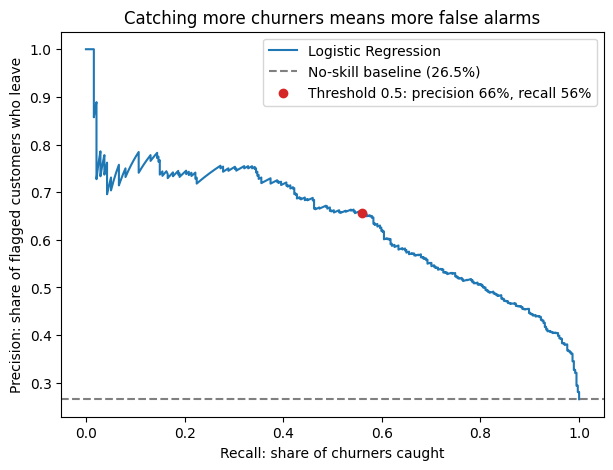

In [39]:
# The precision-recall curve



from sklearn.metrics import precision_recall_curve

# precision and recall at every possible threshold
precision, recall, thresholds = precision_recall_curve(y_test, proba_test)

# where the default threshold 0.5 lands: precision and recall when flagging proba >= 0.5
flag = proba_test >= 0.5
p05, r05 = y_test.values[flag].mean(), flag[y_test.values == 1].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, label="Logistic Regression")
ax.axhline(y_test.mean(), color="grey", linestyle="--", label="No-skill baseline (26.5%)")
ax.scatter(r05, p05, color="tab:red", zorder=3, label=f"Threshold 0.5: precision {p05:.0%}, recall {r05:.0%}")
ax.set_title("Catching more churners means more false alarms")
ax.set_xlabel("Recall: share of churners caught")
ax.set_ylabel("Precision: share of flagged customers who leave")
ax.legend()
plt.show()

**What I see**
- At the default threshold 0.5: precision 66%, recall 56%. We miss 44% of churners.
- Lowering the threshold catches more churners at the cost of more false alarms (e.g. ~75% recall at ~50% precision).
- The curve stays well above the 26.5% no-skill line at every threshold.
- 0.5 has no business meaning; the threshold should come from the cost of a missed churner vs a wasted offer.

In [40]:
# Out-of-fold probabilities (for choosing the threshold)


from sklearn.model_selection import cross_val_predict

# each training customer gets a churn probability from a model trained on the other 4 folds
# so these behave like predictions on unseen customers, without using the test set
proba_oof = cross_val_predict(final_model, X_train, y_train, cv=5, method="predict_proba")[:, 1]

print(len(proba_oof), "out-of-fold probabilities | mean:", round(proba_oof.mean(), 3))

5634 out-of-fold probabilities | mean: 0.265


In [42]:
# threshold by cost

import numpy as np

# ASSUMED costs: placeholders, the business would supply the real numbers
offer_cost = 100   # every flagged customer gets a retention offer
lost_cost = 500    # revenue lost when a churner isn't flagged and leaves

grid = np.arange(0.05, 0.95, 0.01)
costs = []
for t in grid:
    flag = proba_oof >= t
    missed = ((~flag) & (y_train.values == 1)).sum()
    costs.append(flag.sum() * offer_cost + missed * lost_cost)

best_t = grid[np.argmin(costs)]
print(f"Cheapest threshold: {best_t:.2f}")

Cheapest threshold: 0.21


**What I see**
- Assumed costs: '$'100 per retention offer, '$'500 per churner we miss (placeholders; real numbers come from the business).
- Cheapest threshold on out-of-fold predictions: 0.21, next to the 0.20 predicted by "flag if probability x $500 > $100".
- They agree because the probabilities are well calibrated.
- The threshold was chosen on training data (out-of-fold), not the test set.

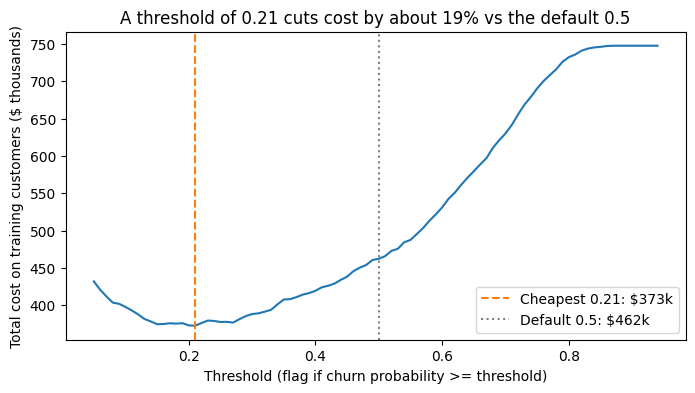

In [44]:
# Cost at every threshold


costs = np.array(costs)
cost_05 = costs[np.argmin(np.abs(grid - 0.5))]   # cost at the default threshold

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid, costs / 1000)
ax.axvline(best_t, color="tab:orange", linestyle="--", label=f"Cheapest {best_t:.2f}: ${costs.min()/1000:.0f}k")
ax.axvline(0.5, color="grey", linestyle=":", label=f"Default 0.5: ${cost_05/1000:.0f}k")
ax.set_title("A threshold of 0.21 cuts cost by about 19% vs the default 0.5")
ax.set_xlabel("Threshold (flag if churn probability >= threshold)")
ax.set_ylabel("Total cost on training customers ($ thousands)")
ax.legend()
plt.show()

**What I see**
- Threshold 0.21 costs $373k vs $462k at 0.5: about 19% ($89k) cheaper on the training customers.

- The cost is flat between ~0.15 and ~0.27, so the choice is robust to small changes in the assumed costs.

- At high thresholds nobody is flagged and every churner is missed (~1,495 x $500 = ~$748k), which matches the plateau.

In [45]:
# Apply the threshold to the test set


from sklearn.metrics import confusion_matrix

# compare the chosen threshold with the default on unseen customers
for t in [best_t, 0.5]:
    flag_test = (proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, flag_test).ravel()
    cost = (tp + fp) * offer_cost + fn * lost_cost
    print(f"Threshold {t:.2f}: caught {tp}, missed {fn}, wasted offers {fp} | "
          f"precision {tp/(tp+fp):.0%}, recall {tp/(tp+fn):.0%} | cost ${cost/1000:.0f}k")



Threshold 0.21: caught 317, missed 57, wasted offers 352 | precision 47%, recall 85% | cost $95k
Threshold 0.50: caught 209, missed 165, wasted offers 109 | precision 66%, recall 56% | cost $114k


**What I see (test set, 1,409 customers)**
- Threshold 0.21: catches 85% of churners (317 of 374), 352 wasted offers, cost $95k.
- Default 0.5: catches 56% (209), 109 wasted offers, cost $114k.
- 0.21 is ~17% cheaper on unseen customers, close to the ~19% on training data, so the choice generalizes.
- Caveat: this assumes every offer keeps the customer. With a 50% success rate, the best threshold would be ~0.40. The real offer success rate is the key business input.

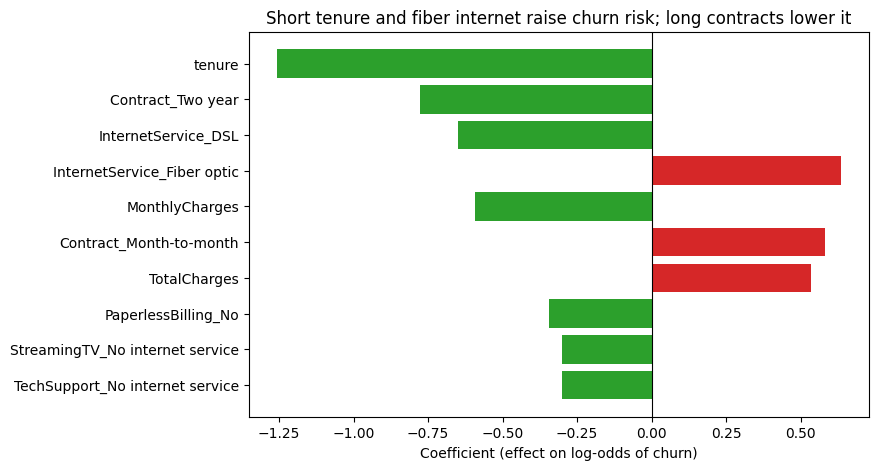

In [46]:
# What drives churn (logistic regression coefficients)


# one coefficient per model input; positive = raises churn risk, negative = lowers it
names = final_model[0].get_feature_names_out()
coefs = pd.Series(final_model[-1].coef_[0], index=names)
coefs.index = coefs.index.str.split("__").str[1]   # drop the "standardscaler__" / "onehotencoder__" prefix

# 10 biggest effects by size; red raises churn, green lowers it
top = coefs[coefs.abs().sort_values().index].tail(10)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=["tab:red" if v > 0 else "tab:green" for v in top.values])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Short tenure and fiber internet raise churn risk; long contracts lower it")
ax.set_xlabel("Coefficient (effect on log-odds of churn)")
plt.show()

**What I see**
- Tenure has the biggest effect: ~2 more years (1 std) cuts the odds of churning to ~29%.
- Fiber optic (~1.9x odds) and month-to-month contracts raise risk; two-year contracts and DSL lower it.
- MonthlyCharges is negative even though churners pay more: fiber (the expensive plan) already carries that effect.
- TotalCharges (+) and tenure (-) are strongly correlated (0.83), so the model splits the effect; neither can be read alone.
- "No internet service" repeats across columns, so its effect is split between copies.

### Save the model and threshold

In [48]:
import joblib
from pathlib import Path

# save the fitted pipeline (preparation + model) and the chosen threshold together
Path("../models").mkdir(exist_ok=True)
joblib.dump({"model": final_model, "threshold": round(float(best_t), 2)}, "../models/churn_model.joblib")

# check: reload it and make sure it gives the same probabilities as before
saved = joblib.load("../models/churn_model.joblib")
print("Threshold:", saved["threshold"])
print("Same predictions:", (saved["model"].predict_proba(X_test)[:, 1] == proba_test).all())

Threshold: 0.21
Same predictions: True
